# Marketing Campaign Analysis
---
1. Understanding the Problem Statement
2. Data Collection
3. Data Checks to perform
4. Exploratory data analysis
5. Data Pre-Processing
6. Model Training
7. Choose best model
---

## 1. Problem Statement
- This project aims to understand how a customer’s response to a marketing campaign (measured through purchase behavior and campaign acceptance) is influenced by various demographic and behavioral variables such as their Age, Education Level, Marital Status, Income, Number of Children and Teenagers in Household, Product Purchase History (e.g., wine, meat, gold), Web and Store Visit Frequency, and their Enrollment Duration with the company. By analyzing these factors, the project seeks to identify the most influential attributes that drive campaign success and customer engagement.

## 2. Data collection
- Data source - [Marketing campaign - Kaggle](https://www.kaggle.com/datasets/rodsaldanha/arketing-campaign)
- Dataset size - 2240 Rows * 29 Columns

### 2.1. Importing libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

In [65]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
sns.set(style="whitegrid",palette="pastel")
warnings.filterwarnings("ignore")


### 2.2. Data reading

In [4]:
df = pd.read_csv("data/marketing_campaign.csv",sep='\t')
df.shape

(2240, 29)

Previewing data

In [5]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


### 2.3. Data information
---
- **AcceptedCmp1** - 1 if customer accepted the offer in the 1st campaign, 0 otherwise
- **AcceptedCmp2** - 1 if customer accepted the offer in the 2nd campaign, 0 otherwise
- **AcceptedCmp3** - 1 if customer accepted the offer in the 3rd campaign, 0 otherwise
- **AcceptedCmp4** - 1 if customer accepted the offer in the 4th campaign, 0 otherwise
- **AcceptedCmp5** - 1 if customer accepted the offer in the 5th campaign, 0 otherwise
- **Response (target)** - 1 if customer accepted the offer in the last campaign, 0 otherwise
- **Complain** - 1 if customer complained in the last 2 years
- **DtCustomer** - date of customer’s enrolment with the company
- **Education** - customer’s level of education
- **Marital** - customer’s marital status
- **Kidhome** - number of small children in customer’s household
- **Teenhome** - number of teenagers in customer’s household
- **Income** - customer’s yearly household income
- **MntFishProducts** - amount spent on fish products in the last 2 years
- **MntMeatProducts** - amount spent on meat products in the last 2 years
- **MntFruits** - amount spent on fruits products in the last 2 years
- **MntSweetProducts** - amount spent on sweet products in the last 2 years
- **MntWines** - amount spent on wine products in the last 2 years
- **MntGoldProds** - amount spent on gold products in the last 2 years
- **NumDealsPurchases** - number of purchases made with discount
- **NumCatalogPurchases** - number of purchases made using catalogue
- **NumStorePurchases** - number of purchases made directly in stores
- **NumWebPurchases** - number of purchases made through company’s web site
- **NumWebVisitsMonth** - number of visits to company’s web site in the last month
- **Recency** - number of days since the last purchase 

## 3.1. Data checks to perform
---
- **3.1.** Check missing values
- **3.2.** Check Duplicates
- **3.3.** Check Data-types
- **3.4.** Check the number of unique values of each column
- **3.5.** Check statistics of dataset
- **3.6.** Check various categories present in the different categorical column

### 3.1. Check missing values

In [6]:
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

Fixed missing values in "**Income**" column

In [7]:
df['Income'].fillna(df['Income'].mean(), inplace=True)

### 3.2. Check duplicates

In [8]:
df.duplicated().sum()

np.int64(0)

There is no duplicate value in dataset

### 3.3. Check data-types

In [9]:
df.dtypes

ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

Data type conversion for better analysis

In [10]:
# converted to boolean
df['Kidhome'] = df['Kidhome'].astype('bool')
df['Teenhome'] = df['Teenhome'].astype('bool')
df['AcceptedCmp1'] = df['AcceptedCmp1'].astype('bool')
df['AcceptedCmp2'] = df['AcceptedCmp2'].astype('bool')
df['AcceptedCmp3'] = df['AcceptedCmp3'].astype('bool')
df['AcceptedCmp4'] = df['AcceptedCmp4'].astype('bool')
df['AcceptedCmp5'] = df['AcceptedCmp5'].astype('bool')
df['Complain'] = df['Complain'].astype('bool')
df['Response'] = df['Response'].astype('bool')

# converted to datetime
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')

# converted to int16
df['Year_Birth'] = df['Year_Birth'].astype('int16')
df['Recency'] = df['Recency'].astype('int16')
df['MntWines'] = df['MntWines'].astype('int16')
df['MntFruits'] = df['MntFruits'].astype('int16')
df['MntMeatProducts'] = df['MntMeatProducts'].astype('int16')
df['MntFishProducts'] = df['MntFishProducts'].astype('int16')
df['MntSweetProducts'] = df['MntSweetProducts'].astype('int16')
df['MntGoldProds'] = df['MntGoldProds'].astype('int16')
df['NumDealsPurchases'] = df['NumDealsPurchases'].astype('int16')
df['NumCatalogPurchases'] = df['NumCatalogPurchases'].astype('int16')
df['NumStorePurchases'] = df['NumStorePurchases'].astype('int16')
df['NumWebPurchases'] = df['NumWebPurchases'].astype('int16')
df['NumWebVisitsMonth'] = df['NumWebVisitsMonth'].astype('int16')

# converted to int8
df['Z_CostContact'] = df['Z_CostContact'].astype('int8')
df['Z_Revenue'] = df['Z_Revenue'].astype('int8')


### 3.4. Check the number of unique values of each column

In [11]:
df.nunique()

ID                     2240
Year_Birth               59
Education                 5
Marital_Status            8
Income                 1975
Kidhome                   2
Teenhome                  2
Dt_Customer             663
Recency                 100
MntWines                776
MntFruits               158
MntMeatProducts         558
MntFishProducts         182
MntSweetProducts        177
MntGoldProds            213
NumDealsPurchases        15
NumWebPurchases          15
NumCatalogPurchases      14
NumStorePurchases        14
NumWebVisitsMonth        16
AcceptedCmp3              2
AcceptedCmp4              2
AcceptedCmp5              2
AcceptedCmp1              2
AcceptedCmp2              2
Complain                  2
Z_CostContact             1
Z_Revenue                 1
Response                  2
dtype: int64

### 3.5. Check statistics

In [12]:
df.describe()

,ID,Year_Birth,Income,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Z_CostContact,Z_Revenue
count,2240.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0
mean,5592.159821,1968.805804,52247.251354,2013-07-10 10:01:42.857142784,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,3.0,11.0
min,0.000000,1893.000000,1730.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0
25%,2828.250000,1959.000000,35538.750000,2013-01-16 00:00:00,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,3.0,11.0
50%,5458.500000,1970.000000,51741.500000,2013-07-08 12:00:00,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,3.0,11.0
75%,8427.750000,1977.000000,68289.750000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,3.0,11.0
max,11191.000000,1996.000000,666666.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,3.0,11.0
std,3246.662198,11.984069,25037.797168,NaN,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.0,0.0


**INSIGHTS**
- **Age** – Over 50% of the customers are older than 50 years, with the age of customers ranging from **24 to 117 years**.
- **Income** - Over 50% of the customer earning above **$ 51741**
- **Recency** - Overall 50% of the customer made a purchase within the **last 49 days**
- **Purchases** - Average number of store-purchases are greater than average number of web-purchases that shows customer slightly preference for in-store shopping.
---
 [ *dataset is older than 5 year* ]

### 3.6. Check various categorical present in the different categorical column.

In [13]:
df.dtypes

ID                              int64
Year_Birth                      int16
Education                      object
Marital_Status                 object
Income                        float64
Kidhome                          bool
Teenhome                         bool
Dt_Customer            datetime64[ns]
Recency                         int16
MntWines                        int16
MntFruits                       int16
MntMeatProducts                 int16
MntFishProducts                 int16
MntSweetProducts                int16
MntGoldProds                    int16
NumDealsPurchases               int16
NumWebPurchases                 int16
NumCatalogPurchases             int16
NumStorePurchases               int16
NumWebVisitsMonth               int16
AcceptedCmp3                     bool
AcceptedCmp4                     bool
AcceptedCmp5                     bool
AcceptedCmp1                     bool
AcceptedCmp2                     bool
Complain                         bool
Z_CostContac

In [17]:
df['Education'].value_counts() / df.shape[0] * 100

Education
Graduation    50.312500
PhD           21.696429
Master        16.517857
2n Cycle       9.062500
Basic          2.410714
Name: count, dtype: float64

In [18]:
df['Marital_Status'].value_counts() / df.shape[0] * 100

Marital_Status
Married     38.571429
Together    25.892857
Single      21.428571
Divorced    10.357143
Widow        3.437500
Alone        0.133929
Absurd       0.089286
YOLO         0.089286
Name: count, dtype: float64

**INSIGHT**
- 50% of customers are only completed their **graduation**
- Overall 38% of customers are married and 21% customers are single.

# 4. Exporatory Data Analysis

### Feature Engineering

In [20]:
df['month_enrolled'] = df['Dt_Customer'].dt.month
df['year_enrolled'] = df['Dt_Customer'].dt.year
df['age'] = df['year_enrolled'] - df['Year_Birth']

### Univariate Analysis

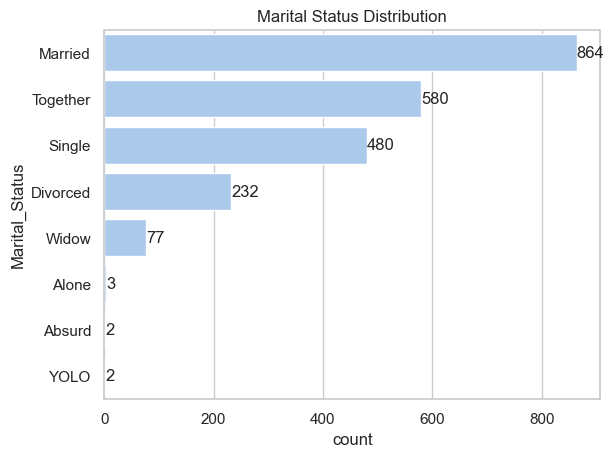

In [92]:
sns.countplot(df['Marital_Status'].sort_values(ascending=False), order=df['Marital_Status'].value_counts().index)
plt.bar_label(plt.gca().containers[0])
plt.title('Marital Status Distribution')
plt.show()

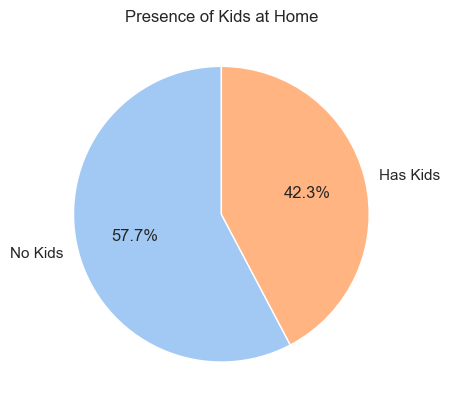

In [91]:
plt.pie(df['Kidhome'].value_counts(), labels=['No Kids', 'Has Kids'], autopct='%1.1f%%', startangle=90)
plt.title('Presence of Kids at Home')
plt.show()

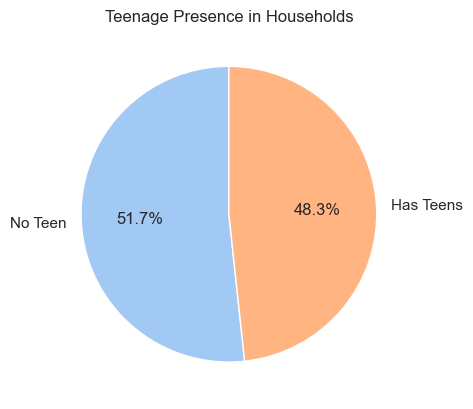

In [89]:
plt.pie(df['Teenhome'].value_counts(), labels=['No Teen', 'Has Teens'], autopct='%1.1f%%', startangle=90)
plt.title('Teenage Presence in Households')
plt.show()

In [69]:
print("Married + Has kids :",(df[(df['Marital_Status'] == 'Married') & (df['Kidhome'])].shape[0] / df.shape[0]) * 100)
print("Married + Has teens :",(df[(df['Marital_Status'] == 'Married') & (df['Teenhome'])].shape[0] / df.shape[0]) * 100)
print("Percentage of Married :",(df[(df['Marital_Status'] == 'Married')].shape[0] / df.shape[0]) * 100)

Married + Has kids : 16.65178571428571
Married + Has teens : 18.75
Percentage of Married : 38.57142857142858


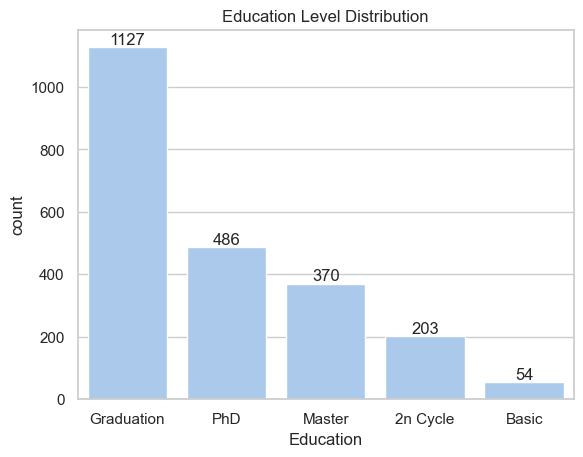

In [88]:
sns.countplot(x='Education', data=df, order=df['Education'].value_counts().index)
plt.bar_label(plt.gca().containers[0])
plt.title('Education Level Distribution')
plt.show()

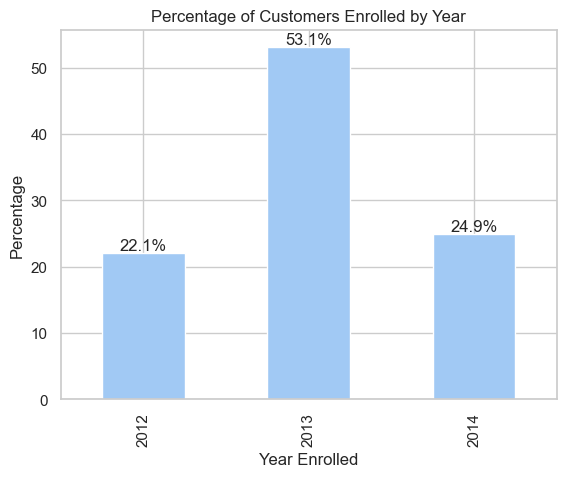

In [87]:
df['year_enrolled'].value_counts(normalize=True).sort_index().mul(100).plot(kind='bar')
plt.bar_label(plt.gca().containers[0], fmt='%.1f%%')
plt.title('Percentage of Customers Enrolled by Year')
plt.ylabel('Percentage')
plt.xlabel('Year Enrolled')
plt.show()

In [64]:
df.head(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,month_enrolled,year_enrolled,age
0,5524,1957,Graduation,Single,58138.0,False,False,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,False,False,False,False,False,False,3,11,True,9,2012,55
1,2174,1954,Graduation,Single,46344.0,True,True,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,False,False,False,False,False,False,3,11,False,3,2014,60
2,4141,1965,Graduation,Together,71613.0,False,False,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,False,False,False,False,False,False,3,11,False,8,2013,48
3,6182,1984,Graduation,Together,26646.0,True,False,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,False,False,False,False,False,False,3,11,False,2,2014,30
4,5324,1981,PhD,Married,58293.0,True,False,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,False,False,False,False,False,False,3,11,False,1,2014,33


**INSIGHTS**
- As per above chart and insights most of customers marital status is **Married** and highest education level is **Graduation**
- 57% of customers have **No kids**, 51% of customers have **No teens**
- 16% of customers got married have  **kids** and 18% of customers have married have **Teens**